# Exercise 6.1

**Goal:** given a dataset `data_6_1.csv` containing 200 data points, apply K-means to cluster them into $K=5$ clusters. Visualize the result.

**Note:** You should run the algorithm multiple times and select the result which corresponds to the lowest cost $J$.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load the dataset
df = pd.read_csv('data_6_1.csv')
X = df.values

print(f"Dataset shape: {X.shape}")
df.head()

Dataset shape: (200, 2)


,x1,x2
0,10.28,8.92
1,-2.62,3.98
2,9.16,10.11
3,-4.32,10.84
4,0.20,10.70


## K-Means Clustering

We will run the K-Means algorithm with $K=5$.  
To satisfy the requirement of running multiple times and selecting the lowest cost, we can use the `n_init` parameter in scikit-learn's `KMeans`. 
It automatically runs the algorithm `n_init` times with different centroid seeds and selects the model with the lowest inertia (cost J).

In [2]:
# K = 5 clusters
K = 5

# n_init=20 ensures we run the algorithm 20 times and pick the best result (lowest inertia)
kmeans = KMeans(n_clusters=K, n_init=20, random_state=42)
kmeans.fit(X)

# The best cost (inertia)
print(f"Lowest Cost J (Inertia): {kmeans.inertia_:.2f}")

# Cluster labels and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

Lowest Cost J (Inertia): 582.06


## Visualization

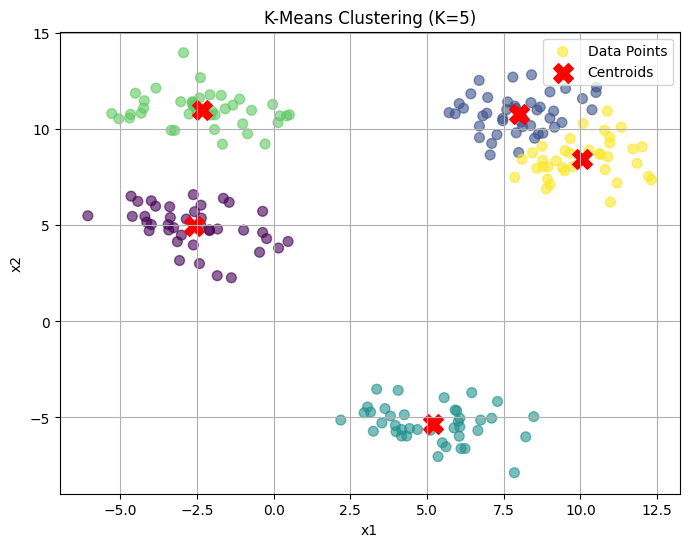

In [3]:
plt.figure(figsize=(8, 6))

# Plot data points colored by cluster info
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.6, label='Data Points')

# Plot centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title(f'K-Means Clustering (K={K})')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()